**Nota sobre este notebook**

Esta es una prueba preliminar ("V1") de detección sobre fotos reales de
nevera, usando un modelo YOLOv8m **preentrenado en COCO sin fine-tuning**
(clases genéricas en inglés traducidas manualmente al español), no el
modelo final entrenado sobre Fruits-360 (`best_fruits.pt`).

La validación real del detector final sobre imágenes multi-objeto
(Experimento 3 de la memoria, subconjunto `test-multiple_fruits` de
Fruits-360) está documentada en el notebook
`03_experimento_fruits360_yolov8n_1.ipynb` (Paso 7) y en el Capítulo 5
de la memoria.


In [3]:
!pip install ultralytics --quiet

════════════════════════════════════════════════════════════
  VALIDACIÓN V1 — YOLOv8 en imágenes de nevera
  TFM Sistema Inteligente de Gestión Alimentaria
════════════════════════════════════════════════════════════

📂 PASO 1: Sube tus fotos de nevera
   (Selecciona todas a la vez con Ctrl+clic o Cmd+clic)



Saving firda-faradiba-GNISAgm05kQ-unsplash.jpg to firda-faradiba-GNISAgm05kQ-unsplash (1).jpg
Saving img_truco-conservar-verduras-nevera-hd-1200x550-cc.jpg to img_truco-conservar-verduras-nevera-hd-1200x550-cc (1).jpg

✅ 2 imagen(es) subida(s) correctamente.

📦 PASO 2: Cargando modelo YOLOv8m...
   (Primera vez: descarga ~6 MB, espera un momento)

✅ Modelo cargado.

════════════════════════════════════════════════════════════
  PASO 3: Procesando imágenes
  Para cada foto verás lo que detectó YOLO.
  Escribe los ingredientes reales cuando se te pida.
════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  [1/2]  firda-faradiba-GNISAgm05kQ-unsplash (1).jpg
────────────────────────────────────────────────────────────


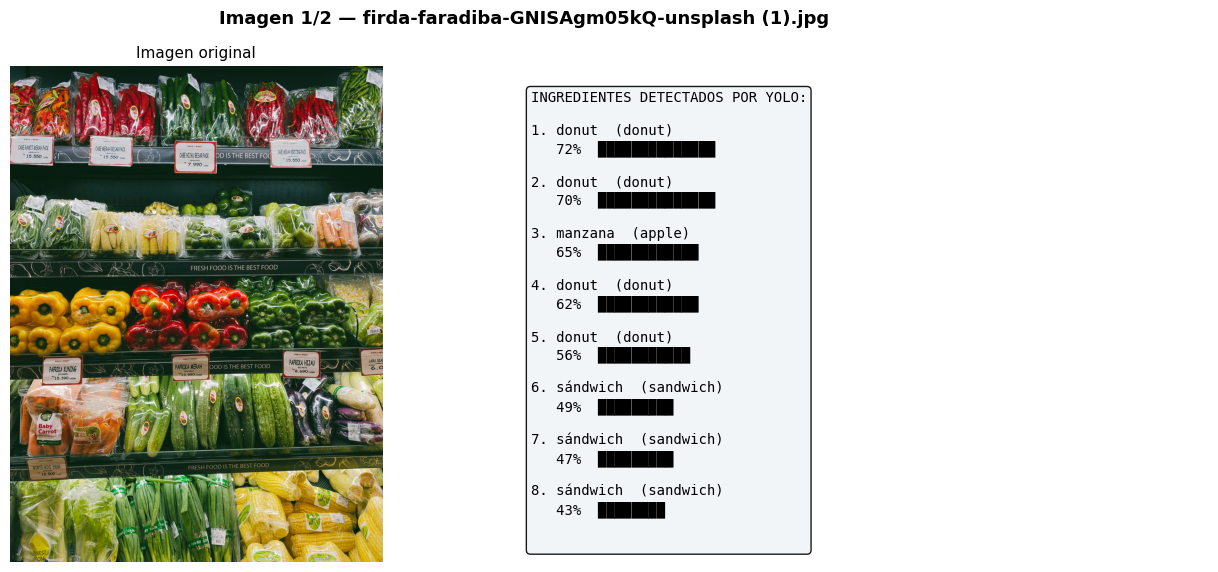


  YOLO detectó 8 objeto(s):
    • donut (donut) — 72% confianza
    • donut (donut) — 70% confianza
    • manzana (apple) — 65% confianza
    • donut (donut) — 62% confianza
    • donut (donut) — 56% confianza
    • sándwich (sandwich) — 49% confianza
    • sándwich (sandwich) — 47% confianza
    • sándwich (sandwich) — 43% confianza

  ¿Qué ingredientes hay REALMENTE en esta imagen?
  Escríbelos separados por comas.
  Ejemplo:  manzana, leche, zanahoria, queso
  (Escribe SALTAR si la imagen no sirve)
  → pimiento rojo, pimiento verde, pimiento amarillo, maiz, puerro, zanahorias

  📊 Precisión: 0%  |  Recall: 0%  |  F1: 0%

────────────────────────────────────────────────────────────
  [2/2]  img_truco-conservar-verduras-nevera-hd-1200x550-cc (1).jpg
────────────────────────────────────────────────────────────


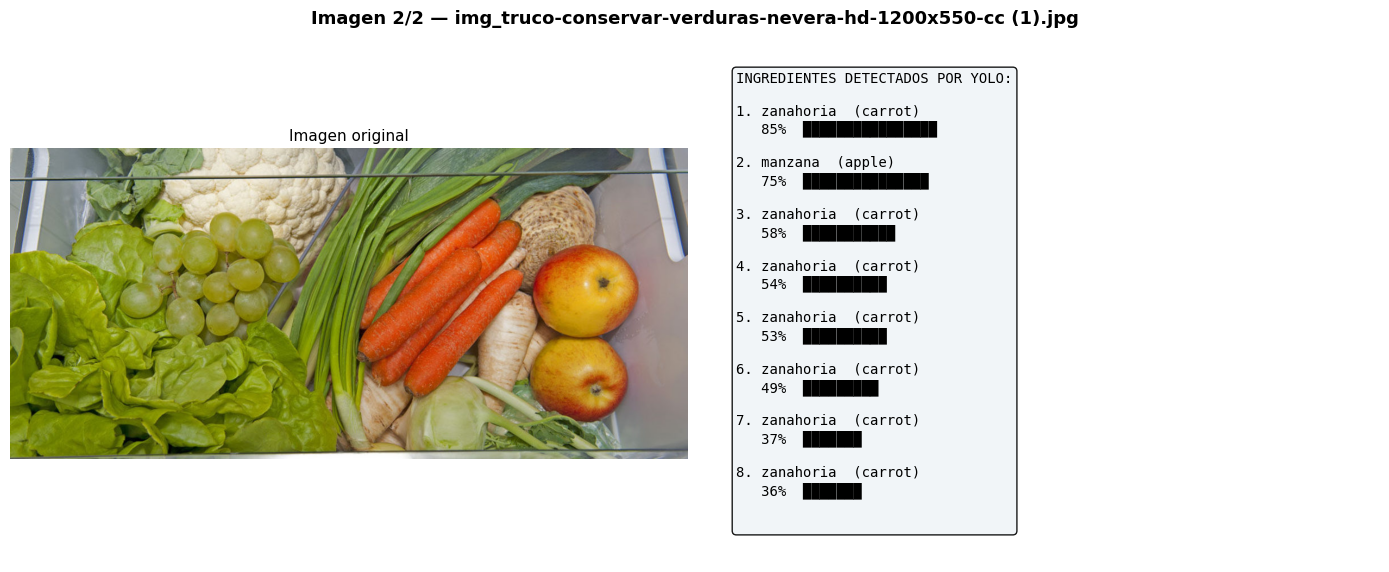


  YOLO detectó 8 objeto(s):
    • zanahoria (carrot) — 85% confianza
    • manzana (apple) — 75% confianza
    • zanahoria (carrot) — 58% confianza
    • zanahoria (carrot) — 54% confianza
    • zanahoria (carrot) — 53% confianza
    • zanahoria (carrot) — 49% confianza
    • zanahoria (carrot) — 37% confianza
    • zanahoria (carrot) — 36% confianza

  ¿Qué ingredientes hay REALMENTE en esta imagen?
  Escríbelos separados por comas.
  Ejemplo:  manzana, leche, zanahoria, queso
  (Escribe SALTAR si la imagen no sirve)
  → lechuga, uvas, coliflor, manzana, apio, zanahoria

  📊 Precisión: 50%  |  Recall: 33%  |  F1: 40%

════════════════════════════════════════════════════════════
  RESUMEN FINAL — VALIDACIÓN V1
════════════════════════════════════════════════════════════
  Imágenes analizadas:   2
  Precisión media:       25.0%
  Recall medio:          16.7%
  F1-score medio:        20.0%
  Total aciertos (VP):   2
  Total errores (FP):    7
  Total omisiones (FN):  10
════════════════

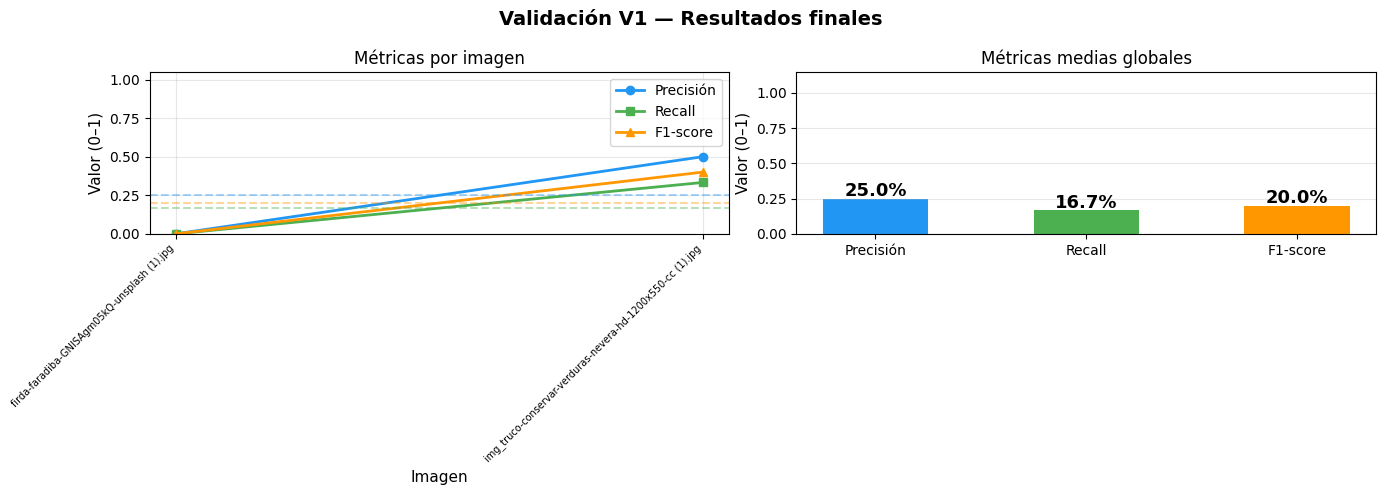


📥 Descargando archivos de resultados...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ¡Listo! Guarda estos archivos para el Capítulo 5 de tu TFM.
   • resultados_v1.csv  → tabla de datos
   • grafico_v1_final.png → gráfico de métricas


In [9]:
import os
import io
import shutil
from pathlib import Path

import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output
from google.colab import files
from ultralytics import YOLO

# ── Configuración ─────────────────────────────────────────────────────────────
CONFIANZA_MINIMA = 0.30
CARPETA_TEMP     = "/content/imagenes_nevera"

TRADUCCIONES = {
    "banana": "plátano", "apple": "manzana", "orange": "naranja",
    "broccoli": "brócoli", "carrot": "zanahoria", "bottle": "botella",
    "sandwich": "sándwich", "bowl": "bol", "cup": "vaso/taza",
    "cake": "pastel", "pizza": "pizza", "hot dog": "salchicha",
    "donut": "donut", "wine glass": "copa", "egg": "huevo",
    "tomato": "tomate", "lettuce": "lechuga", "lemon": "limón",
    "strawberry": "fresa", "grapes": "uva", "peach": "melocotón",
}

# ── Paso 1: Subir imágenes ────────────────────────────────────────────────────
print("═" * 60)
print("  VALIDACIÓN V1 — YOLOv8 en imágenes de nevera")
print("  TFM Sistema Inteligente de Gestión Alimentaria")
print("═" * 60)
print("\n📂 PASO 1: Sube tus fotos de nevera")
print("   (Selecciona todas a la vez con Ctrl+clic o Cmd+clic)\n")

os.makedirs(CARPETA_TEMP, exist_ok=True)
archivos_subidos = files.upload()

# Guardar en carpeta temporal
rutas_imagenes = []
for nombre, contenido in archivos_subidos.items():
    ruta = os.path.join(CARPETA_TEMP, nombre)
    with open(ruta, "wb") as f:
        f.write(contenido)
    rutas_imagenes.append((nombre, ruta))

print(f"\n✅ {len(rutas_imagenes)} imagen(es) subida(s) correctamente.")

# ── Paso 2: Cargar modelo YOLOv8 ─────────────────────────────────────────────
print("\n📦 PASO 2: Cargando modelo YOLOv8m...")
print("   (Primera vez: descarga ~6 MB, espera un momento)\n")
modelo = YOLO("yolov8m.pt")
print("✅ Modelo cargado.")

# ── Paso 3: Procesar cada imagen ──────────────────────────────────────────────
print("\n" + "═" * 60)
print("  PASO 3: Procesando imágenes")
print("  Para cada foto verás lo que detectó YOLO.")
print("  Escribe los ingredientes reales cuando se te pida.")
print("═" * 60)

resultados = []

for idx, (nombre, ruta) in enumerate(rutas_imagenes, 1):

    print(f"\n{'─' * 60}")
    print(f"  [{idx}/{len(rutas_imagenes)}]  {nombre}")
    print("─" * 60)

    # Ejecutar YOLO
    yolo_result = modelo(ruta, conf=CONFIANZA_MINIMA, iou=0.5, verbose=False)
    detecciones = []
    for r in yolo_result:
        for box in r.boxes:
            etiqueta = modelo.names[int(box.cls)]
            confianza = float(box.conf)
            detecciones.append((etiqueta, round(confianza, 3)))
    detecciones.sort(key=lambda x: x[1], reverse=True)

    # ── Mostrar imagen con panel de resultados ────────────────────────────────
    imagen_bgr = cv2.imread(ruta)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"Imagen {idx}/{len(rutas_imagenes)} — {nombre}",
        fontsize=13, fontweight="bold"
    )

    axes[0].imshow(imagen_rgb)
    axes[0].set_title("Imagen original", fontsize=11)
    axes[0].axis("off")

    axes[1].axis("off")
    if detecciones:
        texto = "INGREDIENTES DETECTADOS POR YOLO:\n\n"
        for i, (etq, conf) in enumerate(detecciones, 1):
            trad = TRADUCCIONES.get(etq, etq)
            barra = "█" * int(conf * 20)
            texto += f"{i}. {trad}  ({etq})\n"
            texto += f"   {conf:.0%}  {barra}\n\n"
    else:
        texto = (
            "YOLO no detectó ningún objeto\n"
            "con confianza ≥ 30 %.\n\n"
            "Posibles causas:\n"
            "• Imagen con poca luz\n"
            "• Alimentos dentro de envases\n"
            "• Ángulo o distancia difícil"
        )

    axes[1].text(
        0.05, 0.95, texto,
        transform=axes[1].transAxes,
        fontsize=10, verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#f0f4f8", alpha=0.9)
    )

    plt.tight_layout()
    plt.savefig(f"/content/deteccion_{idx:02d}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Consola: listar detecciones ───────────────────────────────────────────
    if detecciones:
        print(f"\n  YOLO detectó {len(detecciones)} objeto(s):")
        for etq, conf in detecciones:
            trad = TRADUCCIONES.get(etq, etq)
            print(f"    • {trad} ({etq}) — {conf:.0%} confianza")
    else:
        print("\n  YOLO no detectó ningún objeto.")

    # ── Pedir ground truth ────────────────────────────────────────────────────
    print("\n  ¿Qué ingredientes hay REALMENTE en esta imagen?")
    print("  Escríbelos separados por comas.")
    print("  Ejemplo:  manzana, leche, zanahoria, queso")
    print("  (Escribe SALTAR si la imagen no sirve)")

    respuesta = input("  → ").strip()

    if respuesta.upper() == "SALTAR":
        print("  ⏭️  Imagen saltada.")
        continue

    ground_truth = [x.strip().lower() for x in respuesta.split(",") if x.strip()]

    # ── Calcular métricas ─────────────────────────────────────────────────────
    detectados_es = set()
    for etq, _ in detecciones:
        detectados_es.add(TRADUCCIONES.get(etq, etq).lower())
        detectados_es.add(etq.lower())

    gt_set = set(ground_truth)
    vp = len(gt_set & detectados_es)
    fp = len(detectados_es - gt_set)
    fn = len(gt_set - detectados_es)

    precision = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    recall    = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    print(f"\n  📊 Precisión: {precision:.0%}  |  Recall: {recall:.0%}  |  F1: {f1:.0%}")

    resultados.append({
        "imagen":                    nombre,
        "num_detectados_yolo":       len(detecciones),
        "num_reales_ground_truth":   len(ground_truth),
        "detectados_yolo":           "; ".join(
            [f"{TRADUCCIONES.get(e,e)} ({c:.0%})" for e, c in detecciones]
        ),
        "ground_truth":              "; ".join(ground_truth),
        "verdaderos_positivos":      vp,
        "falsos_positivos":          fp,
        "falsos_negativos":          fn,
        "precision":                 round(precision, 3),
        "recall":                    round(recall, 3),
        "f1_score":                  round(f1, 3),
    })

# ── Paso 4: Resumen y descarga ────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  RESUMEN FINAL — VALIDACIÓN V1")
print("═" * 60)

if not resultados:
    print("  ⚠️  No se procesó ninguna imagen.")
else:
    df = pd.DataFrame(resultados)

    print(f"  Imágenes analizadas:   {len(df)}")
    print(f"  Precisión media:       {df['precision'].mean():.1%}")
    print(f"  Recall medio:          {df['recall'].mean():.1%}")
    print(f"  F1-score medio:        {df['f1_score'].mean():.1%}")
    print(f"  Total aciertos (VP):   {int(df['verdaderos_positivos'].sum())}")
    print(f"  Total errores (FP):    {int(df['falsos_positivos'].sum())}")
    print(f"  Total omisiones (FN):  {int(df['falsos_negativos'].sum())}")
    print("═" * 60)

    # ── Gráfico final de métricas ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Validación V1 — Resultados finales", fontsize=14, fontweight="bold")

    # Gráfico de líneas por imagen
    x = range(len(df))
    ax = axes[0]
    ax.plot(x, df["precision"], "o-", label="Precisión", color="#2196F3", linewidth=2)
    ax.plot(x, df["recall"],    "s-", label="Recall",    color="#4CAF50", linewidth=2)
    ax.plot(x, df["f1_score"],  "^-", label="F1-score",  color="#FF9800", linewidth=2)
    ax.axhline(df["precision"].mean(), color="#2196F3", linestyle="--", alpha=0.4)
    ax.axhline(df["recall"].mean(),    color="#4CAF50", linestyle="--", alpha=0.4)
    ax.axhline(df["f1_score"].mean(),  color="#FF9800", linestyle="--", alpha=0.4)
    ax.set_xlabel("Imagen", fontsize=11)
    ax.set_ylabel("Valor (0–1)", fontsize=11)
    ax.set_title("Métricas por imagen", fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["imagen"].tolist(), rotation=45, ha="right", fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Gráfico de barras de medias
    ax2 = axes[1]
    metricas_medias = {
        "Precisión": df["precision"].mean(),
        "Recall":    df["recall"].mean(),
        "F1-score":  df["f1_score"].mean(),
    }
    colores = ["#2196F3", "#4CAF50", "#FF9800"]
    bars = ax2.bar(metricas_medias.keys(), metricas_medias.values(), color=colores, width=0.5)
    for bar, val in zip(bars, metricas_medias.values()):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.1%}", ha="center", fontsize=13, fontweight="bold")
    ax2.set_ylim(0, 1.15)
    ax2.set_title("Métricas medias globales", fontsize=12)
    ax2.set_ylabel("Valor (0–1)", fontsize=11)
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("/content/grafico_v1_final.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Guardar y descargar CSV ───────────────────────────────────────────────
    ruta_csv = "/content/resultados_v1.csv"
    df.to_csv(ruta_csv, index=False, encoding="utf-8-sig")

    print("\n📥 Descargando archivos de resultados...")
    files.download(ruta_csv)
    files.download("/content/grafico_v1_final.png")
    print("\n✅ ¡Listo! Guarda estos archivos para el Capítulo 5 de tu TFM.")
    print("   • resultados_v1.csv  → tabla de datos")
    print("   • grafico_v1_final.png → gráfico de métricas")